In [1]:
import fastf1
import pandas as pd
import numpy as np

fastf1.Cache.enable_cache('f1_cache')

RACES_2026 = ['Australia', 'Japan', 'Saudi Arabia', 'Austria', 'Great Britain']
MODEL_PIT = {'Great Britain': 23, 'Japan': 23}   # your solved circuits (Silverstone, Suzuka)

first_stops = {}
for ev in RACES_2026:
    try:
        s = fastf1.get_session(2026, ev, 'R')
        s.load(telemetry=False, weather=True)
        laps = s.laps
        wet = laps['Compound'].isin(['INTERMEDIATE','WET']).mean() > 0.3
        stops = []
        for drv, g in laps.groupby('Driver'):
            g = g.sort_values('LapNumber')
            pit_laps = g[g['PitInTime'].notna()]['LapNumber'].tolist()
            if pit_laps:
                # was the first stop under green? check TrackStatus of that lap
                row = g[g['LapNumber'] == pit_laps[0]]
                ts = str(row['TrackStatus'].iloc[0]) if len(row) else '1'
                green = all(c not in ts for c in ['4','5','6','7'])
                stops.append({'driver': drv, 'first_pit': pit_laps[0], 'green': green})
        first_stops[ev] = {'stops': pd.DataFrame(stops), 'wet': wet,
                           'n_laps': int(laps['LapNumber'].max())}
        print(f"{ev}: {len(stops)} drivers, wet={wet}, race={first_stops[ev]['n_laps']} laps")
    except Exception as e:
        print(f"{ev}: FAILED ({e})")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

Australia: 19 drivers, wet=False, race=58 laps


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Japan: 22 drivers, wet=False, race=53 laps


logger      WARNING 	Failed to load session info data!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
core        WARNING 	Failed to load extended driver information!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
core        WARNING 	Failed to load driver list and session results!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
logger      WARNING 	Failed to load session status data!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
logger      WARNING 	Failed to load total lap count!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
logger      WARNING 	Failed to load track status data!
req            INFO 	No 

Saudi Arabia: FAILED (The data you are trying to access has not been loaded yet. See `Session.load`)


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Failed to align laps for driver

Austria: 22 drivers, wet=False, race=71 laps


core        WARNING 	Driver 63 completed the race distance 00:00.530000 before the recorded end of the session.
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '3', '12', '81', '44', '6', '1', '16', '30', '41', '5', '27', '10', '87', '43', '31', '23', '14', '18', '55', '11', '77']


Great Britain: 22 drivers, wet=False, race=71 laps


In [2]:
print(f"\n{'Race':15s} {'wet?':>5s} {'model':>6s} {'actual median':>14s} {'IQR':>12s} {'error':>6s}")
print("-" * 65)
for ev, data in first_stops.items():
    df = data['stops']
    green_stops = df[df['green']]['first_pit']
    if len(green_stops) < 5:
        print(f"{ev:15s} {'Y' if data['wet'] else 'n':>5s}   too few green first-stops"); continue
    med = green_stops.median()
    q1, q3 = green_stops.quantile(0.25), green_stops.quantile(0.75)
    model = MODEL_PIT.get(ev)
    err = f"{model - med:+.0f}" if model else "  —"
    mstr = str(model) if model else "—"
    print(f"{ev:15s} {'Y' if data['wet'] else 'n':>5s} {mstr:>6s} {med:>14.0f} {f'[{q1:.0f},{q3:.0f}]':>12s} {err:>6s}")


Race             wet?  model  actual median          IQR  error
-----------------------------------------------------------------
Australia           n   too few green first-stops
Japan               n     23             18      [17,19]     +5
Austria             n      —             18      [14,19]      —
Great Britain       n     23             18      [14,19]     +5


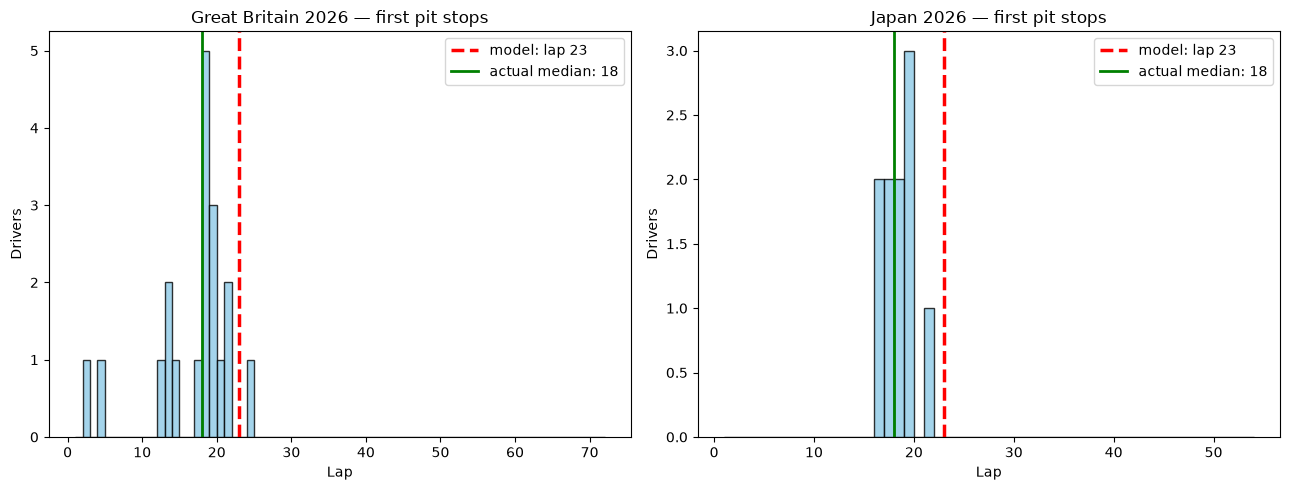

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ev in zip(axes, ['Great Britain', 'Japan']):
    if ev not in first_stops: continue
    df = first_stops[ev]['stops']
    green_stops = df[df['green']]['first_pit']
    ax.hist(green_stops, bins=range(1, first_stops[ev]['n_laps']+2),
            color='#8ecae6', edgecolor='black', alpha=0.8)
    ax.axvline(MODEL_PIT[ev], color='red', lw=2.5, ls='--',
               label=f"model: lap {MODEL_PIT[ev]}")
    ax.axvline(green_stops.median(), color='green', lw=2,
               label=f"actual median: {green_stops.median():.0f}")
    ax.set_title(f"{ev} 2026 — first pit stops")
    ax.set_xlabel('Lap'); ax.set_ylabel('Drivers'); ax.legend()
plt.tight_layout()
plt.savefig('validation_2026.png', dpi=200, bbox_inches='tight')
plt.show()